# Result Tables

This notebook can be used to generate tables to display results stored in /results/results.csv visually

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../results/results.csv")   # File where Evalutation results are stored

In [2]:
# List of models to loop over. Entries like:
# Model name in results.csv, Display name in table, Degradation type as in results.csv
MODELS = [
    ("microsoft/trocr-base-handwritten", "base", None),
    ("iam_awgn", "AWGN-Model", "awgn"),
    ("iam_blur", "Blur-Model", "blur"),
    ("iam_jpeg_compression", "JPEG-Compression-Model", "jpeg_compression"),
    ("iam_downscale", "Downscale-Model", "downscale"),
    ("iam_combo", "Combination-Model", "combo"),
    ("iam_mixed", "Mixed-Model", "combo"),
]

# Helper containing all degradation + intensity combinations
DEGRADATIONS = [
    ("awgn",              [50, 100, 150, 200, 250]),
    ("blur",              [1.0, 2.0, 3.0, 4.0, 5.0]),
    ("jpeg_compression",  [10, 6, 3, 1]),
    ("downscale",         [35, 30, 25, 20, 15]),
    ("combo",             [1, 2, 3, 4, 5]),
]

# light row bg per method, darker highlight when model matches
METHOD_COLORS = {
    "none":             ("#f0f0f0", None),
    "awgn":             ("#dceeff", "#90c4ff"),
    "blur":             ("#dcffdc", "#90f090"),
    "jpeg_compression": ("#fff3dc", "#ffd990"),
    "downscale":        ("#f5dcff", "#d990ff"),
}


### Help function to render the table of results of one metric for a given dataset

In [3]:
def render_table( dataset, metric):
    data = df[df["dataset"] == dataset]

    none_rows = [("none", "none")] if not data[data["method"] == "none"].empty else []
    deg_rows  = [(method, str(i)) for method, intensities in DEGRADATIONS for i in intensities]
    combos    = none_rows + deg_rows

    lookup = {(r.model, r.method, str(r.intensity)): getattr(r, metric) for r in data.itertuples()}

    col_labels = [m[1] for m in MODELS]
    row_labels = [f"{m}  |  {i}" for m, i in combos]

    cell_text = [
        [f"{lookup.get((orig, method, intensity)) * 100:.2f}%"
        if lookup.get((orig, method, intensity)) is not None else "—"
        for orig, _, __ in MODELS]
        for method, intensity in combos
    ]

    n_cols = len(MODELS)
    n_rows = len(combos)

    fig, ax = plt.subplots(figsize=(max(8, n_cols * 2.0 + 2), max(3, (n_rows + 4) * 0.38)))
    ax.axis("off")

    tbl = ax.table(
        cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
        cellLoc="center", rowLoc="center", loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.4)

    # column headers
    for j in range(n_cols):
        tbl[0, j].set_facecolor("#3a3a3a")
        tbl[0, j].set_text_props(color="white", fontweight="bold")

    # data rows
    for i, (method, intensity) in enumerate(combos):
        row_bg, highlight_bg = METHOD_COLORS.get(method, ("#ffffff", None))
        tbl[i+1, -1].set_facecolor(row_bg)
        tbl[i+1, -1].set_text_props(fontweight="bold")
        for j, (_, __, trained_method) in enumerate(MODELS):
            bg = highlight_bg if (highlight_bg and trained_method == method) else row_bg
            tbl[i+1, j].set_facecolor(bg)

    fig.suptitle(f"{dataset.upper()} — {metric.upper()}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Tables for IAM Dataset

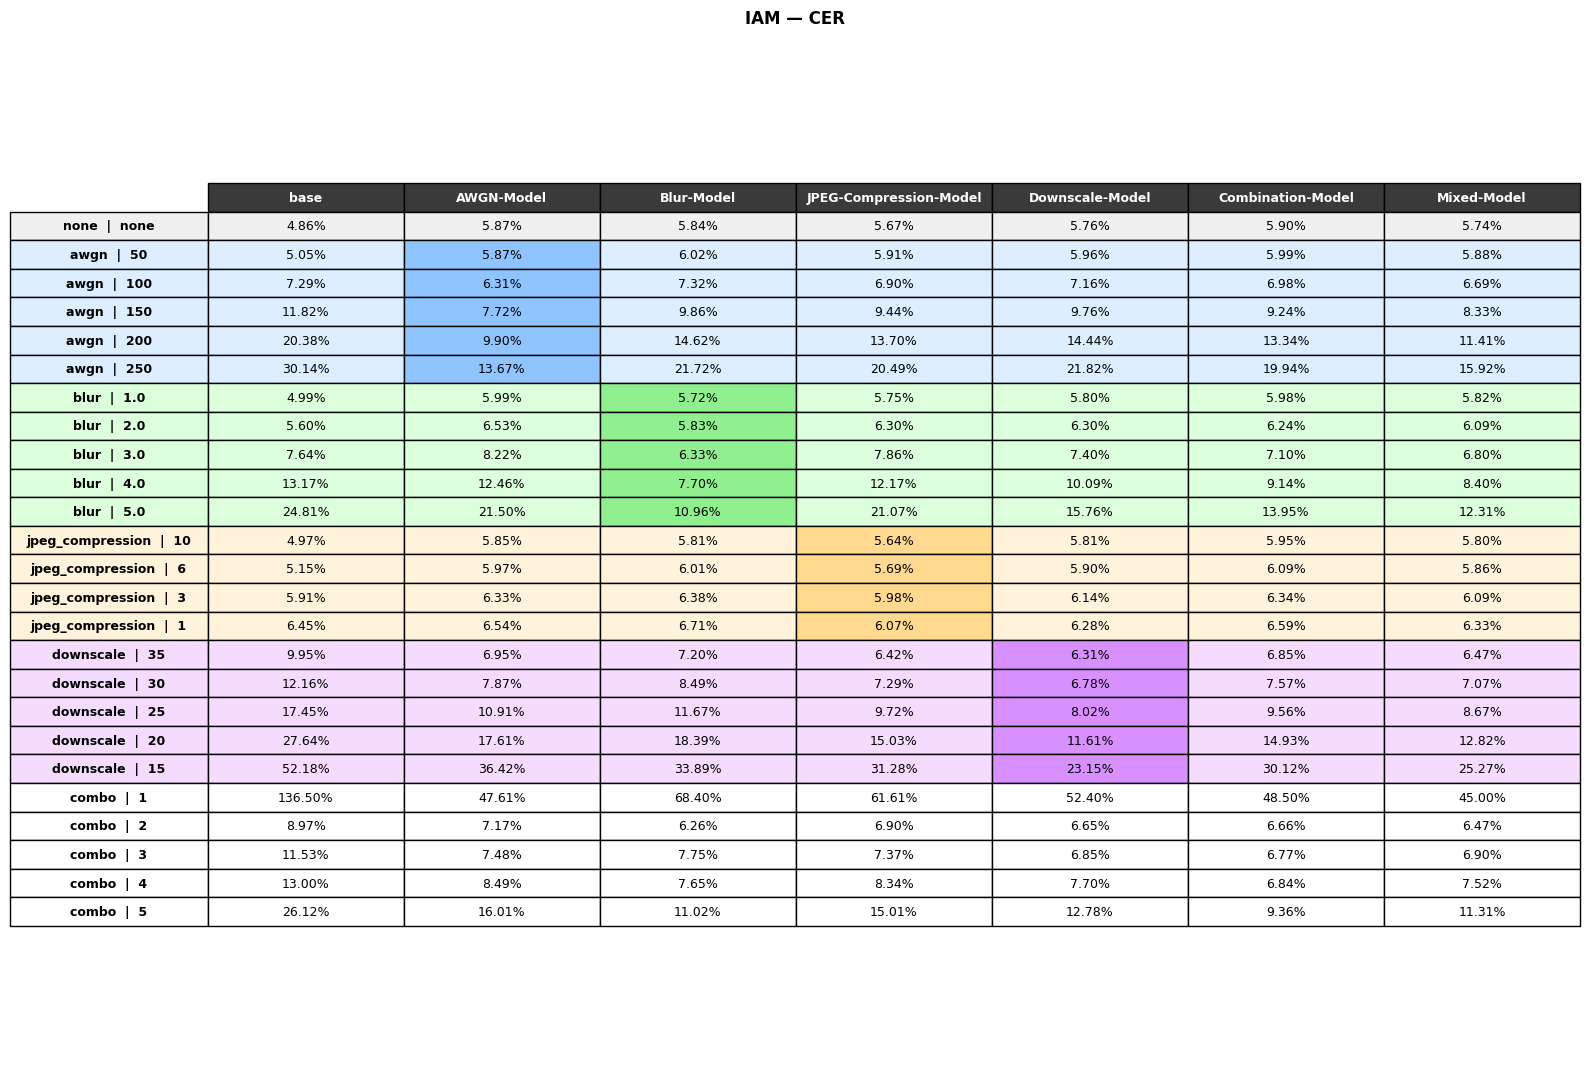

In [4]:
render_table( "iam", "cer")

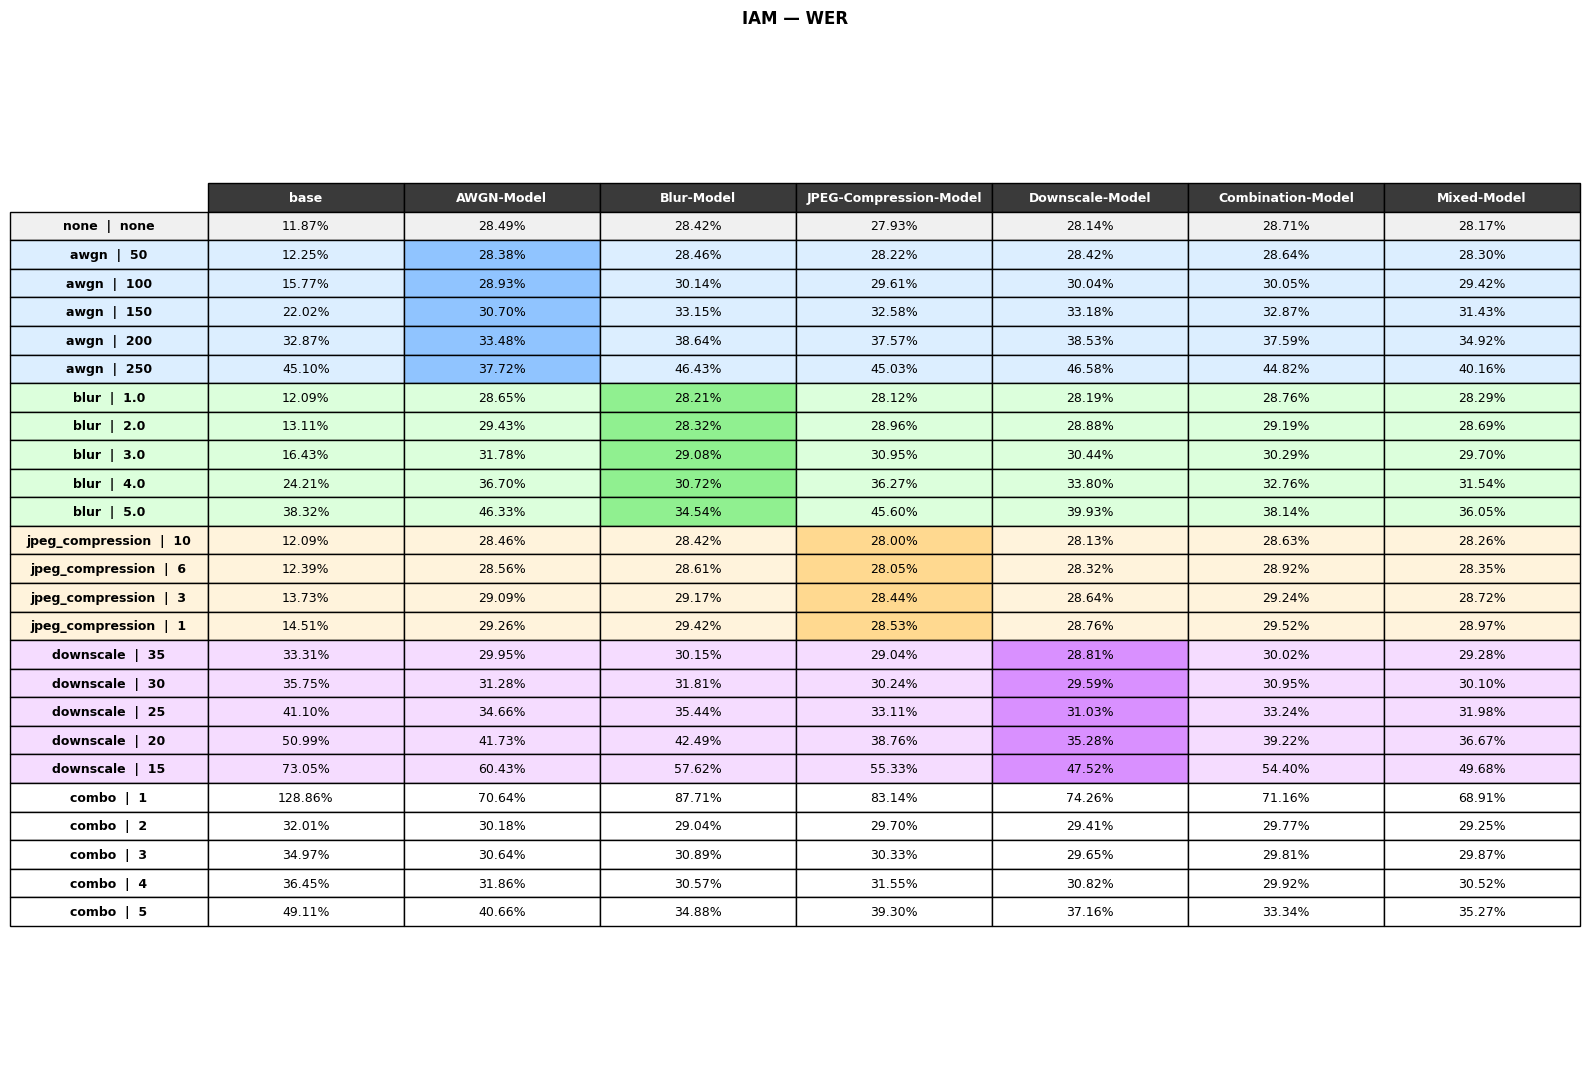

In [5]:
render_table( "iam", "wer")

### Tables for RIMES dataset

In [6]:
MODELS = [
    ("RIMES-base", "base", None),
    ("RIMES_awgn", "AWGN-Model", "awgn"),
    ("RIMES_blur", "Blur-Model", "blur"),
    ("RIMES_jpeg_compression", "JPEG-Compression-Model", "jpeg_compression"),
    ("RIMES_downscale", "Downscale-Model", "downscale"),
    ("RIMES_combo", "Combination-Model", "combo"),
    ("RIMES_mixed", "Mixed-Model", "combo"),
]

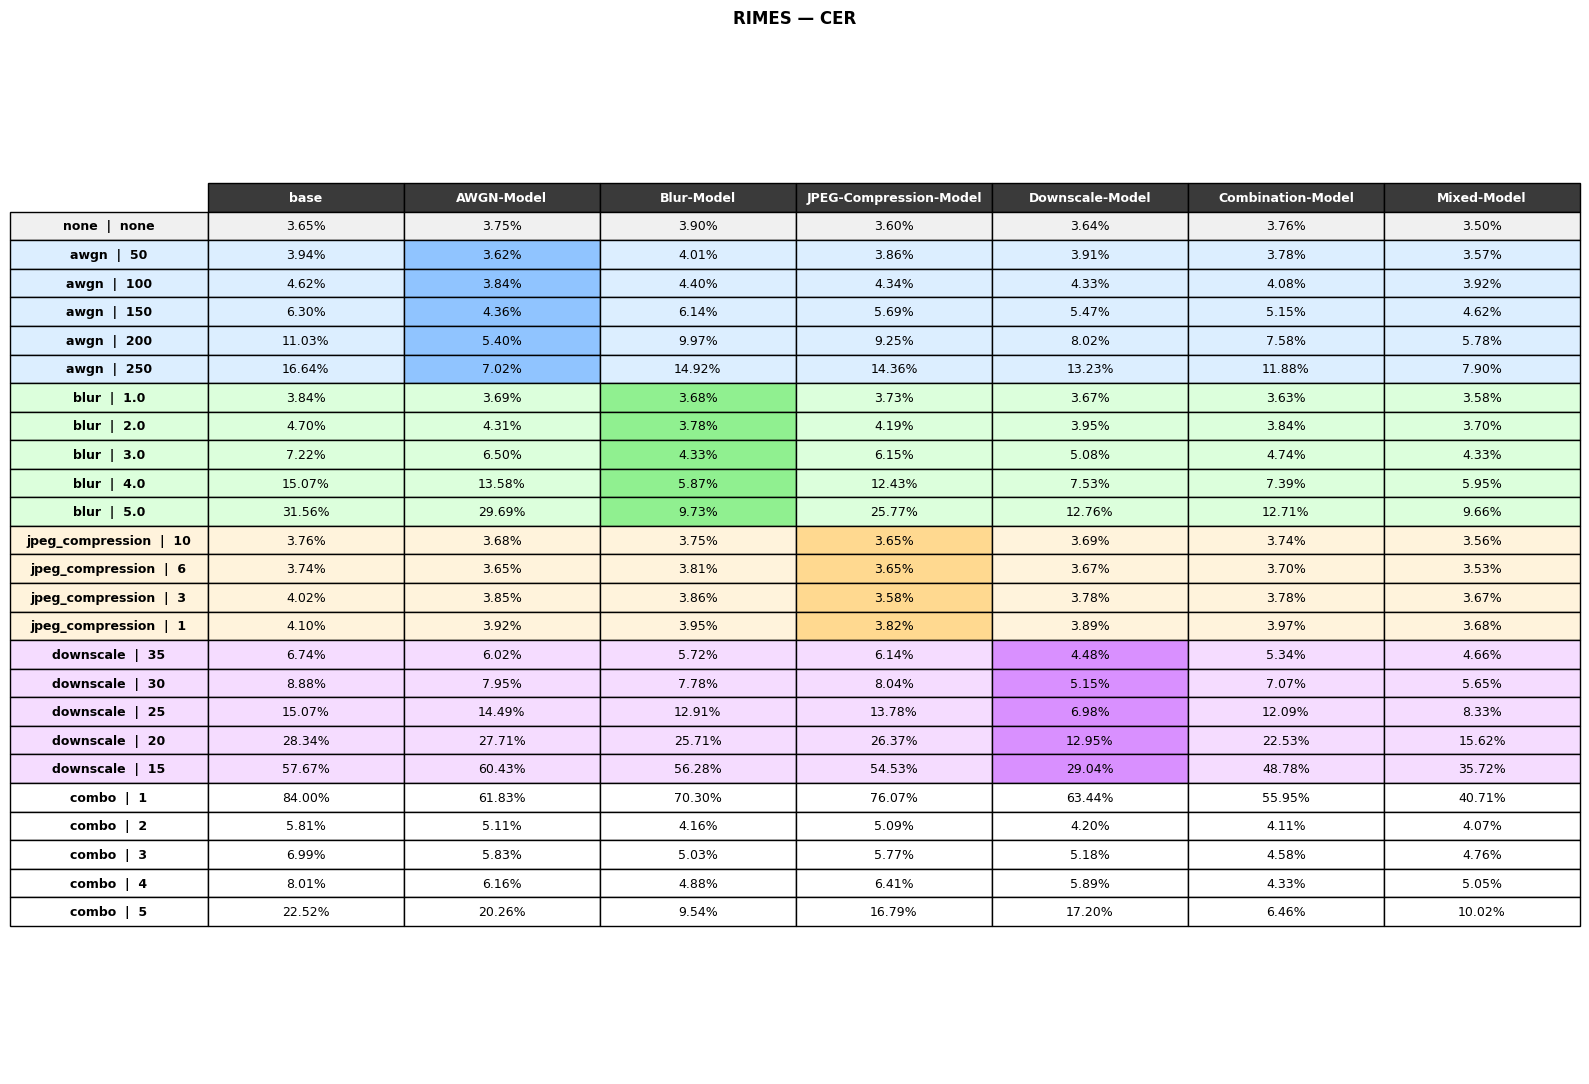

In [7]:
render_table( "rimes", "cer")

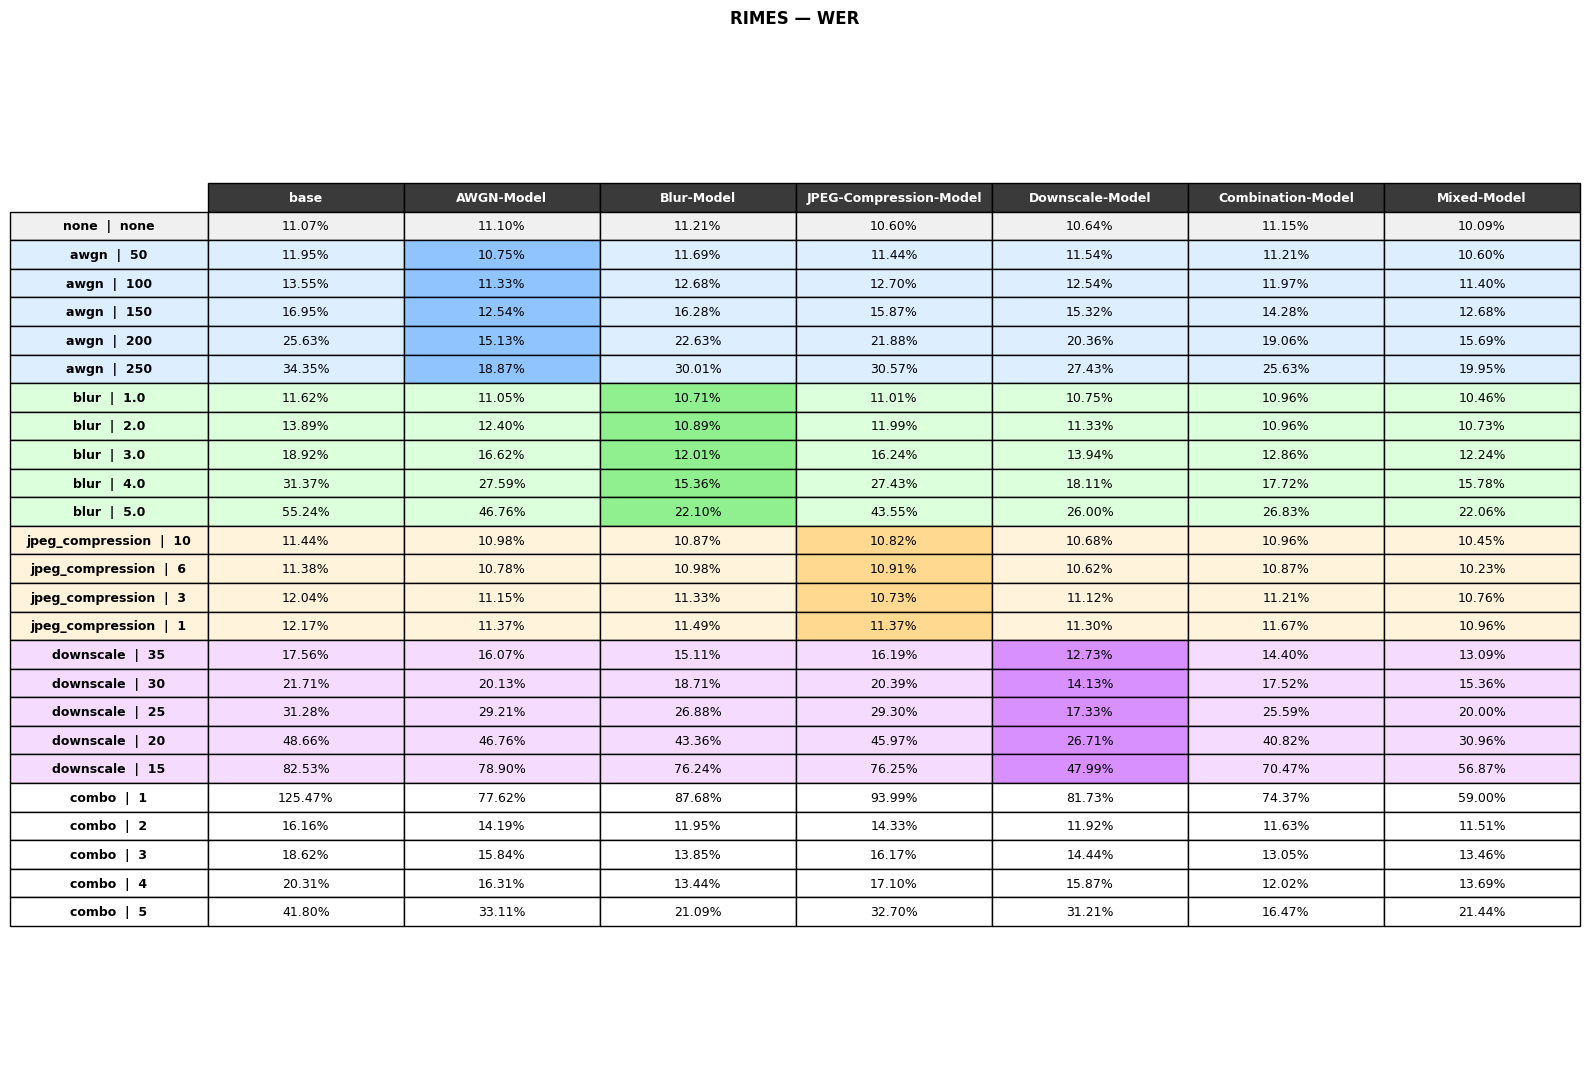

In [8]:
render_table( "rimes", "wer")

### Tables for CATMuS Dataset

In [9]:
MODELS = [
    ("CATMuS_base", "base", None),
    ("CATMuS_awgn", "AWGN-Model", "awgn"),
    ("CATMuS_blur", "Blur-Model", "blur"),
    ("CATMuS_jpeg_compression", "JPEG-Compression-Model", "jpeg_compression"),
    ("CATMuS_downscale", "Downscale-Model", "downscale"),
]

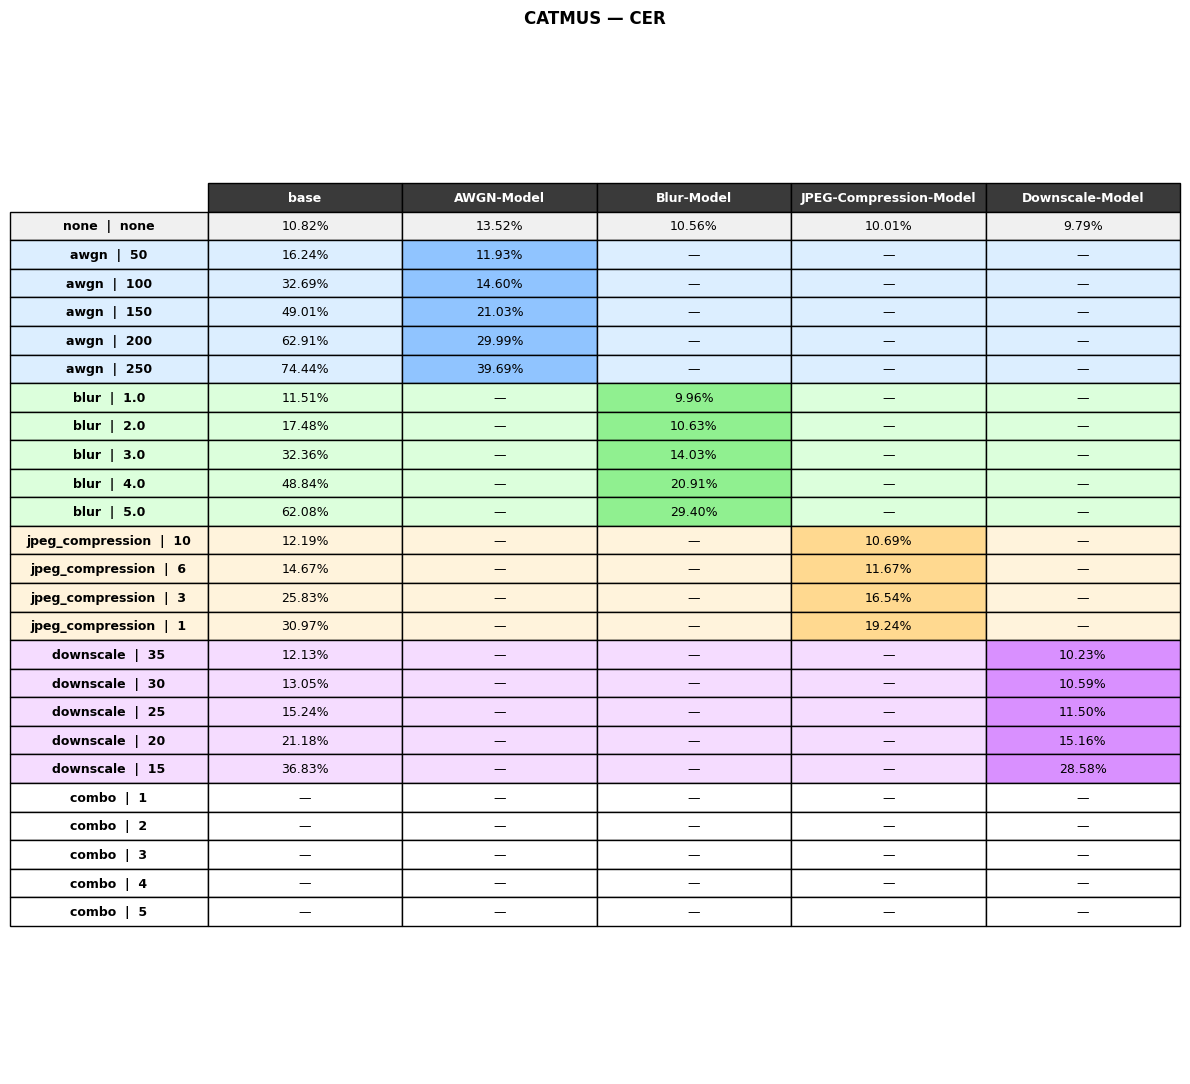

In [10]:
render_table( "catmus", "cer")

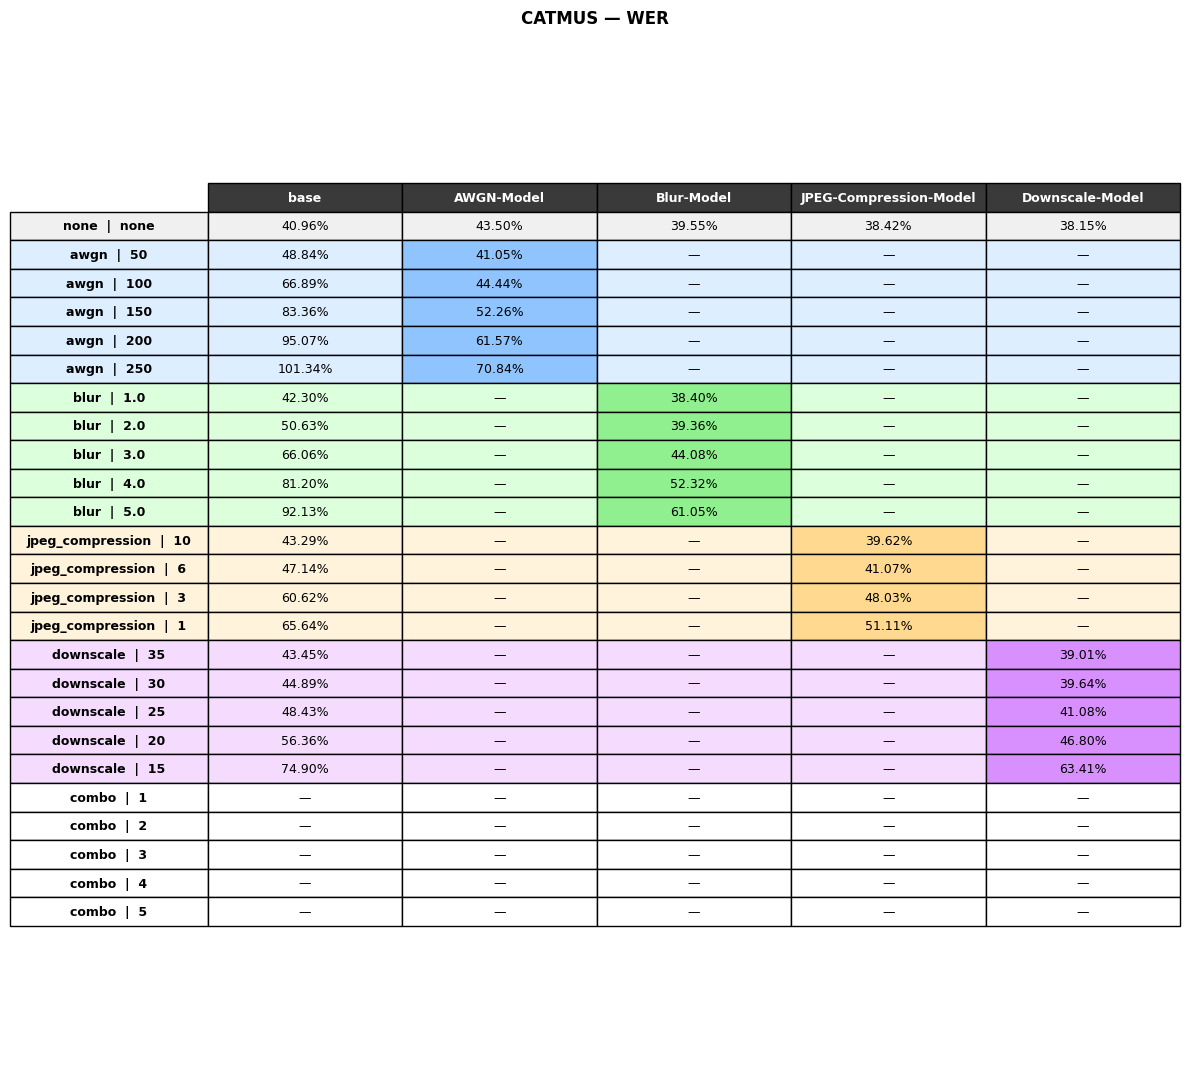

In [11]:
render_table( "catmus", "wer")